<a href="https://colab.research.google.com/github/EugOT/CN-pr-Allen-Brain/blob/main/redl_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

installing dependencies

In [27]:
# @title Install packages
!pip install pip --upgrade --quiet
!pip install brain_observatory_utilities --upgrade --quiet
!pip install pandas --quiet
!pip install seaborn --quiet

Import packages

In [28]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.manifold import TSNE

import brain_observatory_utilities.datasets.optical_physiology.data_formatting as ophys_formatting
import brain_observatory_utilities.utilities.general_utilities as utilities

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

pd.set_option('display.max_columns', 500)

Load Dataset

In [29]:
# read data from cache
# or download if necessary

data_storage_directory = "./tmp"  # Note: this path must exist on your local drive
cache = VisualBehaviorOphysProjectCache.from_s3_cache(cache_dir=data_storage_directory)

session_table = cache.get_ophys_session_table()
experiment_table = cache.get_ophys_experiment_table()

/usr/local/lib/python3.10/dist-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [30]:
print (cache)
session_table.head()


,behavior_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,imaging_plane_group_count,project_code,session_type,session_number,image_set,behavior_type,experience_level,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,num_depths_per_area,ophys_experiment_id,num_targeted_structures
ophys_session_id,,,,,,,,,,,,,,,,,,,,,,,,,
951410079,951520319,"[1018028339, 1018028342, 1018028345, 101802835...",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,4,VisualBehaviorMultiscope,OPHYS_1_images_A,1,images_A,active_behavior,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,4,"[951980471, 951980473, 951980475, 951980479, 9...",2
952430817,952554548,"[1018028339, 1018028345, 1018028354, 1018028357]",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,209,3,VisualBehaviorMultiscope,OPHYS_2_images_A_passive,2,images_A,passive_viewing,Familiar,0,66,1,2019-09-23 08:45:38.490000+00:00,MESO.1,4,"[953659743, 953659745, 953659749, 953659752]",2
954954402,953982960,"[1018028339, 1018028342, 1018028345, 101802835...",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,210,4,VisualBehaviorMultiscope,OPHYS_3_images_A,3,images_A,active_behavior,Familiar,0,67,2,2019-09-24 09:01:31.582000+00:00,MESO.1,4,"[958527464, 958527471, 958527474, 958527479, 9...",2
955775716,956010809,"[1018028339, 1018028342, 1018028345]",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,212,2,VisualBehaviorMultiscope,OPHYS_3_images_A,3,images_A,active_behavior,Familiar,1,68,3,2019-09-26 09:22:21.772000+00:00,MESO.1,4,"[956941841, 956941844, 956941846]",2
957020350,957032492,"[1018028339, 1018028342, 1018028345, 101802835...",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,213,4,VisualBehaviorMultiscope,OPHYS_4_images_B,4,images_B,active_behavior,Novel 1,0,0,4,2019-09-27 08:58:37.005000+00:00,MESO.1,4,"[957759562, 957759564, 957759566, 957759570, 9...",2


from matplotlib import pyplot as plt
_df_15['behavior_session_id'].plot(kind='hist', bins=20, title='behavior_session_id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_16['age_in_days'].plot(kind='hist', bins=20, title='age_in_days')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_17['imaging_plane_group_count'].plot(kind='hist', bins=20, title='imaging_plane_group_count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_18['session_number'].plot(kind='hist', bins=20, title='session_number')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['experience_level'].value_counts()
    for x_label, grp in _df_37.groupby('behavior_type')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('behavior_type')
_ = plt.ylabel('experience_level')

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_38['session_type'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_38, x='behavior_session_id', y='session_type', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_39['image_set'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_39, x='behavior_session_id', y='image_set', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_40['behavior_type'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_40, x='behavior_session_id', y='behavior_type', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_41['experience_level'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_41, x='behavior_session_id', y='experience_level', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [31]:
experiment_table.head()

,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,imaging_depth,targeted_structure,targeted_imaging_depth,imaging_plane_group,project_code,session_type,session_number,image_set,behavior_type,passive,experience_level,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,published_at,isi_experiment_id,file_id
ophys_experiment_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
951980471,951520319,951410079,1018028342,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,150,VISp,150,0,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,0
951980473,951520319,951410079,1018028345,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,225,VISp,225,0,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,1
951980475,951520319,951410079,1018028339,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,75,VISp,75,1,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,2
951980479,951520319,951410079,1018028354,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,150,VISl,150,2,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,3
951980481,951520319,951410079,1018028357,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,225,VISl,225,2,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,4


In [32]:
ophys_session_id = 951410079
session_table.loc[ophys_session_id]

behavior_session_id                                                        951520319
ophys_container_id                 [1018028339, 1018028342, 1018028345, 101802835...
mouse_id                                                                      457841
indicator                                                                    GCaMP6f
full_genotype                          Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt
driver_line                                                           [Sst-IRES-Cre]
cre_line                                                                Sst-IRES-Cre
reporter_line                                             Ai148(TIT2L-GC6f-ICL-tTA2)
sex                                                                                F
age_in_days                                                                      206
imaging_plane_group_count                                                          4
project_code                                                Visua

In [33]:
experiments = {}
ophys_experiment_ids = session_table.loc[ophys_session_id]['ophys_experiment_id']
for ophys_experiment_id in ophys_experiment_ids:
    experiments[ophys_experiment_id] = cache.get_behavior_ophys_experiment(ophys_experiment_id)

In [34]:
experiment = experiments[ophys_experiment_ids[1]]
experiment.cell_specimen_table.head()

,cell_roi_id,height,mask_image_plane,max_correction_down,max_correction_left,max_correction_right,max_correction_up,valid_roi,width,x,y,roi_mask
cell_specimen_id,,,,,,,,,,,,
1086620813,1080744295,17,0,4.0,22.0,3.0,30.0,True,17,293,395,"[[False, False, False, False, False, False, Fa..."
1086621290,1080744315,15,0,4.0,22.0,3.0,30.0,True,16,200,254,"[[False, False, False, False, False, False, Fa..."
1086621434,1080744321,16,0,4.0,22.0,3.0,30.0,True,14,413,247,"[[False, False, False, False, False, False, Fa..."
1086621629,1080744326,20,0,4.0,22.0,3.0,30.0,True,21,271,244,"[[False, False, False, False, False, False, Fa..."
1086621968,1080744337,21,0,4.0,22.0,3.0,30.0,True,16,129,204,"[[False, False, False, False, False, False, Fa..."


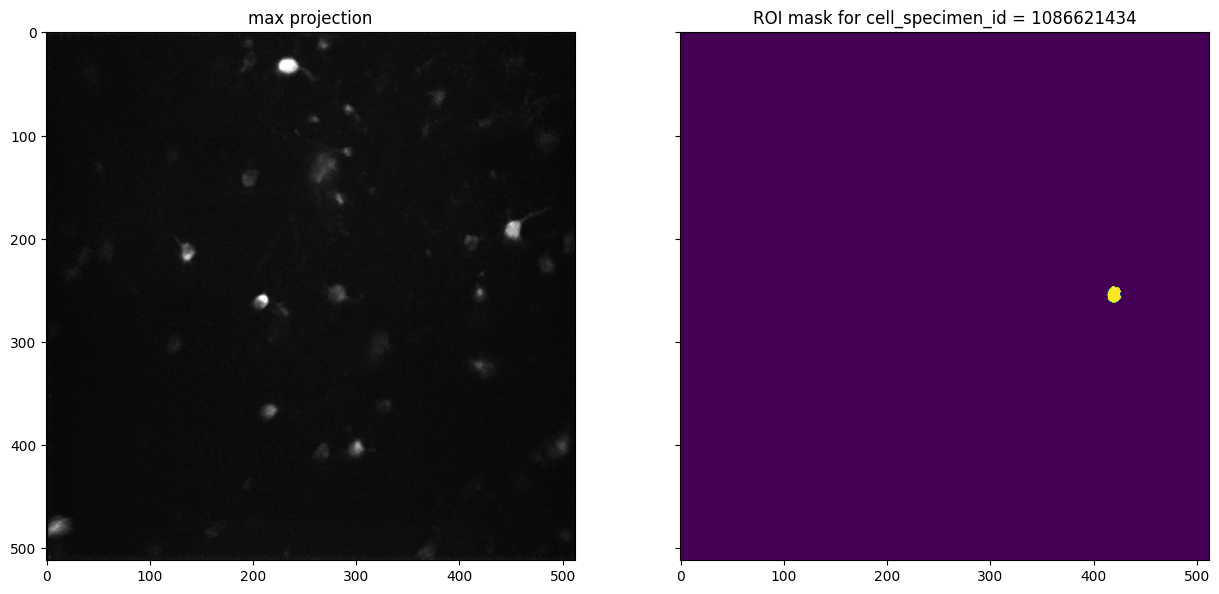

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8), sharex=True, sharey=True)
ax[0].imshow(experiment.max_projection, cmap='gray')
ax[0].set_title('max projection')

cell_specimen_id = experiment.cell_specimen_table.index[2]
ax[1].imshow(experiment.cell_specimen_table.loc[cell_specimen_id]['roi_mask'])
ax[1].set_title('ROI mask for cell_specimen_id = {}'.format(cell_specimen_id))
fig.show()

In [36]:
neural_data = []
for ophys_experiment_id in tqdm(experiments.keys()): #tqdm is a package that shows progress bars for items that are iterated over
    this_experiment = experiments[ophys_experiment_id]
    this_experiment_neural_data = ophys_formatting.build_tidy_cell_df(this_experiment)

    # add some columns with metadata for the experiment
    metadata_keys = [
      'ophys_experiment_id',
      'ophys_session_id',
      'targeted_structure',
      'imaging_depth',
      'equipment_name',
      'cre_line',
      'mouse_id',
      'sex',
    ]
    for metadata_key in metadata_keys:
        this_experiment_neural_data[metadata_key] = this_experiment.metadata[metadata_key]

    # append the data for this experiment to a list
    neural_data.append(this_experiment_neural_data)

# concatate the list of dataframes into a single dataframe
neural_data = pd.concat(neural_data)

100%|██████████| 7/7 [00:02<00:00,  2.86it/s]


In [37]:
neural_data.head()

,timestamps,dff,events,filtered_events,cell_roi_id,cell_specimen_id,ophys_experiment_id,ophys_session_id,targeted_structure,imaging_depth,equipment_name,cre_line,mouse_id,sex
0,9.26356,0.936573,0.000000,0.000000,1080743723,1086613265,951980471,951410079,VISp,150,MESO.1,Sst-IRES-Cre,457841,F
1,9.35677,0.582486,0.000000,0.000000,1080743723,1086613265,951980471,951410079,VISp,150,MESO.1,Sst-IRES-Cre,457841,F
2,9.44998,1.296005,0.556873,0.400762,1080743723,1086613265,951980471,951410079,VISp,150,MESO.1,Sst-IRES-Cre,457841,F
3,9.54318,0.844898,0.000000,0.148502,1080743723,1086613265,951980471,951410079,VISp,150,MESO.1,Sst-IRES-Cre,457841,F
4,9.63639,1.181188,0.467264,0.343829,1080743723,1086613265,951980471,951410079,VISp,150,MESO.1,Sst-IRES-Cre,457841,F


from matplotlib import pyplot as plt
_df_0['timestamps'].plot(kind='hist', bins=20, title='timestamps')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['dff'].plot(kind='hist', bins=20, title='dff')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['events'].plot(kind='hist', bins=20, title='events')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['filtered_events'].plot(kind='hist', bins=20, title='filtered_events')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  from matplotlib import pyplot as plt
  import seaborn as sns
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['timestamps']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'timestamps'}, axis=1)
              .sort_values('timestamps', ascending=True))
  xs = counted['timestamps']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_10.sort_values('timestamps', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('timestamps')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_11['timestamps'].plot(kind='line', figsize=(8, 4), title='timestamps')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_12['dff'].plot(kind='line', figsize=(8, 4), title='dff')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['events'].plot(kind='line', figsize=(8, 4), title='events')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['filtered_events'].plot(kind='line', figsize=(8, 4), title='filtered_events')
plt.gca().spines[['top', 'right']].set_visible(False)

In [38]:
cell_ids = neural_data['cell_specimen_id'].unique()
print('there are {} unique cells'.format(len(cell_ids)))
print('cell ids are: {}'.format(cell_ids))

there are 88 unique cells
cell ids are: [1086613265 1086613823 1086619526 1086614149 1086614351 1086614819
 1086615201 1086615620 1086615837 1086616206 1086619674 1086616398
 1086620813 1086621290 1086621434 1086621629 1086621968 1086622155
 1086622408 1086622595 1086622778 1086623189 1086623621 1086623929
 1086621122 1086619317 1086619511 1086619649 1086619787 1086619928
 1086620268 1086620350 1086621818 1086621907 1086620671 1086620900
 1086606974 1086608913 1086607071 1086607143 1086607195 1086607520
 1086607562 1086608948 1086609859 1086607903 1086608138 1086609169
 1086608195 1086609266 1086608294 1086609334 1086608379 1086608491
 1086609454 1086608577 1086608630 1086608811 1086617208 1086617362
 1086617474 1086620483 1086617875 1086618186 1086618253 1086618338
 1086618511 1086619804 1086618575 1086618656 1086619132 1086619247
 1086609100 1086609503 1086609798 1086610700 1086610123 1086610475
 1086611645 1086611670 1086611915 1086611955 1086612075 1086612204
 1086612438 1086612612

In [39]:
single_cell_timeseries = neural_data.query('cell_specimen_id == 1086613265')
single_cell_timeseries.head()

,timestamps,dff,events,filtered_events,cell_roi_id,cell_specimen_id,ophys_experiment_id,ophys_session_id,targeted_structure,imaging_depth,equipment_name,cre_line,mouse_id,sex
0,9.26356,0.936573,0.000000,0.000000,1080743723,1086613265,951980471,951410079,VISp,150,MESO.1,Sst-IRES-Cre,457841,F
1,9.35677,0.582486,0.000000,0.000000,1080743723,1086613265,951980471,951410079,VISp,150,MESO.1,Sst-IRES-Cre,457841,F
2,9.44998,1.296005,0.556873,0.400762,1080743723,1086613265,951980471,951410079,VISp,150,MESO.1,Sst-IRES-Cre,457841,F
3,9.54318,0.844898,0.000000,0.148502,1080743723,1086613265,951980471,951410079,VISp,150,MESO.1,Sst-IRES-Cre,457841,F
4,9.63639,1.181188,0.467264,0.343829,1080743723,1086613265,951980471,951410079,VISp,150,MESO.1,Sst-IRES-Cre,457841,F


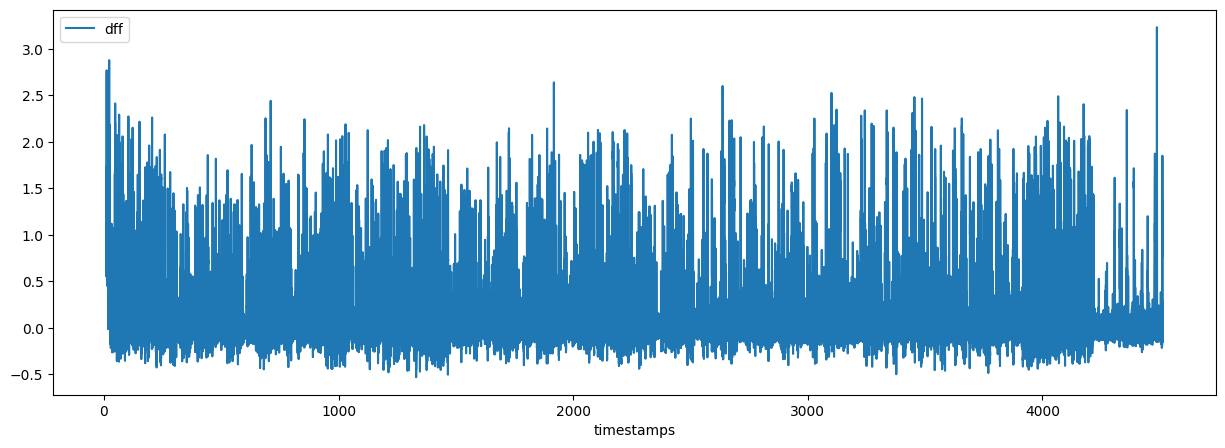

In [40]:
fig, ax = plt.subplots(figsize=(15,5))
single_cell_timeseries.plot(
    x = 'timestamps',
    y = 'dff',
    ax = ax
)
fig.show()